# Multi-Output Time-Series Forecasting using LSTM

**Assignment:** MS22 Theory Assignment 1  
**Topic:** Multi-Output Time-Series Forecasting  
**Dataset:** NIFTY-50 Stock Market Data (2000–2021)  
**Name:** Ayushman Maurya  
**Roll No.:** 25MAM006  
**Source:** Kaggle - NIFTY-50 Stock Market Data  
**CSV selected according to roll number:** `BAJFINANCE.csv`  
**Model used:** LSTM  
**Framework:** PyTorch  
**GitHub Repository:** https://github.com/CodeAlch/Multi-Output-Time-series-Forecasting  

## Objective

The objective of this assignment is to implement an LSTM model for multi-output time-series forecasting.

For this assignment, the stock selected according to my roll number is **BAJFINANCE.csv**.

The model is trained to use the previous **10 trading days** of stock market data and predict the next **5 trading days**.

Each day contains 11 features:

1. Prev Close  
2. Open  
3. High  
4. Low  
5. Last  
6. Close  
7. VWAP  
8. Volume  
9. Turnover  
10. Trades  
11. %Deliverble  

The output is also multi-output because the model predicts all 11 features for the next 5 days.

## Reason for choosing LSTM

LSTM is suitable for time-series forecasting because it can learn patterns from previous time steps.  
Stock market data is sequential, so previous days can contain useful information for future prediction.

I used LSTM instead of a simple RNN because LSTM handles long-term dependencies better and reduces the vanishing gradient problem.

## Importing required libraries

In [38]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

### Environment Configuration

* **Seed Initialization:** Fixing the random seeds ensures that the LSTM's initial weight assignments and the train-test splits remain perfectly consistent across different runs for reliable evaluation.
* **Hardware Acceleration:** Dynamically setting the device allows the notebook to utilize Kaggle's GPU (`cuda`), which is necessary to handle the tensor computations for the 150-epoch training efficiently.

In [39]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("PyTorch version:", torch.__version__)

Using device: cuda
PyTorch version: 2.10.0+cu128


## Loading the dataset

The dataset was added to this Kaggle notebook from the Kaggle input section.  
Since my roll number is 6, the required CSV file is `BAJFINANCE.csv`.

In [40]:
csv_path = "/kaggle/input/datasets/rohanrao/nifty50-stock-market-data/BAJFINANCE.csv"

print("CSV file path automatically found at:", csv_path)

# Load the dataset
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())
display(df.tail())

CSV file path automatically found at: /kaggle/input/datasets/rohanrao/nifty50-stock-market-data/BAJFINANCE.csv
Dataset shape: (5235, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,BAJAUTOFIN,EQ,46.95,49.45,50.75,46.5,50.75,50.75,50.05,7600,3.803800e+10,NaN,NaN,NaN
1,2000-01-04,BAJAUTOFIN,EQ,50.75,53.20,53.20,47.9,48.00,48.10,48.56,5000,2.428000e+10,NaN,NaN,NaN
2,2000-01-05,BAJAUTOFIN,EQ,48.10,46.55,47.40,44.6,44.60,44.60,45.47,3500,1.591450e+10,NaN,NaN,NaN
3,2000-01-06,BAJAUTOFIN,EQ,44.60,43.50,46.00,42.1,46.00,45.25,44.43,6200,2.754750e+10,NaN,NaN,NaN
4,2000-01-07,BAJAUTOFIN,EQ,45.25,48.00,48.00,42.0,42.90,42.90,44.44,3500,1.555550e+10,NaN,NaN,NaN


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
5230,2021-04-26,BAJFINANCE,EQ,4667.80,4690.0,4829.00,4690.00,4744.0,4736.55,4768.93,2903989,1.384893e+15,175366.0,768523.0,0.2646
5231,2021-04-27,BAJFINANCE,EQ,4736.55,4747.0,4889.85,4746.55,4886.0,4865.05,4818.15,2644997,1.274399e+15,148957.0,777955.0,0.2941
5232,2021-04-28,BAJFINANCE,EQ,4865.05,4915.0,5310.00,4915.00,5255.0,5280.90,5158.33,8576454,4.424018e+15,466644.0,1420176.0,0.1656
5233,2021-04-29,BAJFINANCE,EQ,5280.90,5350.0,5525.00,5330.00,5475.0,5484.85,5440.24,7258486,3.948794e+15,392154.0,1537401.0,0.2118
5234,2021-04-30,BAJFINANCE,EQ,5484.85,5350.0,5524.65,5327.70,5449.0,5451.90,5449.83,4124888,2.247992e+15,233718.0,886610.0,0.2149


## Initial data inspection

Before cleaning, I checked:

- Column names
- Data types
- Missing values
- Duplicate rows
- Series column values

In [41]:
print("Column names:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nData types before cleaning:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values before cleaning:")
missing_before = df.isna().sum()
missing_percent_before = (missing_before / len(df)) * 100

missing_summary_before = pd.DataFrame({
    "Missing Count": missing_before,
    "Missing Percent": missing_percent_before.round(2)
})

display(missing_summary_before)

print("\nDuplicate rows before cleaning:", df.duplicated().sum())

if "Series" in df.columns:
    print("\nSeries column value counts:")
    display(df["Series"].value_counts(dropna=False).to_frame("Count"))

Column names:
0 : Date
1 : Symbol
2 : Series
3 : Prev Close
4 : Open
5 : High
6 : Low
7 : Last
8 : Close
9 : VWAP
10 : Volume
11 : Turnover
12 : Trades
13 : Deliverable Volume
14 : %Deliverble

Data types before cleaning:


,Data Type
Date,object
Symbol,object
Series,object
Prev Close,float64
Open,float64
High,float64
Low,float64
Last,float64
Close,float64
VWAP,float64



Missing values before cleaning:


,Missing Count,Missing Percent
Date,0,0.00
Symbol,0,0.00
Series,0,0.00
Prev Close,0,0.00
Open,0,0.00
High,0,0.00
Low,0,0.00
Last,0,0.00
Close,0,0.00
VWAP,0,0.00



Duplicate rows before cleaning: 0

Series column value counts:


,Count
Series,
EQ,5235


## Data cleaning

The following cleaning steps are used:

1. Remove exact duplicate rows.
2. Convert `Date` column into datetime format.
3. Sort data according to date.
4. Remove duplicate dates if present.
5. Convert required columns to numeric format.
6. Replace infinite values with NaN.
7. Drop rows where required 11 features are missing.

The `Trades` column has many missing values in earlier years.  
Since the missing portion is very large, interpolation is not used because it would create artificial financial data.

In [42]:
feature_cols = [
    "Prev Close",
    "Open",
    "High",
    "Low",
    "Last",
    "Close",
    "VWAP",
    "Volume",
    "Turnover",
    "Trades",
    "%Deliverble"
]

price_cols = [
    "Prev Close",
    "Open",
    "High",
    "Low",
    "Last",
    "Close",
    "VWAP"
]

df_clean = df.copy()

# Remove duplicate rows
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
rows_after = len(df_clean)

print("Duplicate rows removed:", rows_before - rows_after)

# Convert Date column
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

invalid_dates = df_clean["Date"].isna().sum()
print("Invalid Date values:", invalid_dates)

df_clean = df_clean.dropna(subset=["Date"])

# Sort by date
df_clean = df_clean.sort_values("Date").reset_index(drop=True)

print("Date range before feature cleaning:", df_clean["Date"].min(), "to", df_clean["Date"].max())

# Remove duplicate dates if any
duplicate_dates = df_clean.duplicated(subset=["Date"]).sum()
print("Duplicate dates before removal:", duplicate_dates)

if duplicate_dates > 0:
    df_clean = df_clean.drop_duplicates(subset=["Date"], keep="last").reset_index(drop=True)

print("Duplicate dates after removal:", df_clean.duplicated(subset=["Date"]).sum())

# Convert required columns to numeric
for col in feature_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Replace infinite values
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print("\nMissing values in selected 11 features before dropping:")
display(df_clean[feature_cols].isna().sum().to_frame("Missing Values"))

# Drop rows where required features are missing
rows_before_drop = len(df_clean)
df_clean = df_clean.dropna(subset=feature_cols).reset_index(drop=True)
rows_after_drop = len(df_clean)

print("Rows dropped due to missing required features:", rows_before_drop - rows_after_drop)
print("Rows after cleaning:", len(df_clean))
print("Date range after cleaning:", df_clean["Date"].min(), "to", df_clean["Date"].max())

display(df_clean.head())

Duplicate rows removed: 0
Invalid Date values: 0
Date range before feature cleaning: 2000-01-03 00:00:00 to 2021-04-30 00:00:00
Duplicate dates before removal: 0
Duplicate dates after removal: 0

Missing values in selected 11 features before dropping:


,Missing Values
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0
Volume,0
Turnover,0
Trades,2779


Rows dropped due to missing required features: 2779
Rows after cleaning: 2456
Date range after cleaning: 2011-06-01 00:00:00 to 2021-04-30 00:00:00


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2011-06-01,BAJFINANCE,EQ,616.70,617.00,636.50,616.00,627.00,631.85,627.01,6894,4.322621e+11,1416.0,3427.0,0.4971
1,2011-06-02,BAJFINANCE,EQ,631.85,625.00,638.90,620.00,634.00,633.45,636.04,2769,1.761205e+11,432.0,1718.0,0.6204
2,2011-06-03,BAJFINANCE,EQ,633.45,625.15,637.80,620.00,623.00,625.00,625.09,51427,3.214631e+12,135.0,50912.0,0.9900
3,2011-06-06,BAJFINANCE,EQ,625.00,620.00,641.00,611.35,611.35,614.00,616.03,5446,3.354910e+11,268.0,4312.0,0.7918
4,2011-06-07,BAJFINANCE,EQ,614.00,604.00,623.95,604.00,619.90,619.15,617.73,5991,3.700840e+11,273.0,4073.0,0.6799


## Stock split / structural break adjustment

BAJFINANCE has a major corporate action / stock split type structural break in the data.  
This creates a sudden artificial price drop in the raw price series.

If this is not handled, the model may learn this artificial drop as a normal market movement.

To reduce this issue, I detected abnormal `Close / Prev Close` ratios and adjusted previous price values to the same scale.

Only price-related columns are adjusted:

- Prev Close
- Open
- High
- Low
- Last
- Close
- VWAP

In [43]:
APPLY_SPLIT_ADJUSTMENT = True

df_clean["close_ratio"] = df_clean["Close"] / df_clean["Prev Close"]

split_candidates = df_clean.loc[
    (df_clean["close_ratio"] < 0.40) | (df_clean["close_ratio"] > 2.50),
    ["Date", "Prev Close", "Close", "close_ratio"]
]

print("Possible stock split / structural break rows:")
display(split_candidates)

if APPLY_SPLIT_ADJUSTMENT and len(split_candidates) > 0:
    for idx, row in split_candidates.iterrows():
        factor = row["close_ratio"]
        
        print("Structural break detected on:", row["Date"])
        print("Adjustment factor:", factor)
        
        # Adjust all previous price values
        if idx > 0:
            df_clean.loc[:idx-1, price_cols] = df_clean.loc[:idx-1, price_cols] * factor
        
        # Adjust only Prev Close on the event row
        df_clean.loc[idx, "Prev Close"] = df_clean.loc[idx, "Prev Close"] * factor

df_clean = df_clean.drop(columns=["close_ratio"], errors="ignore")

print("\nData after split adjustment:")
print("Date range:", df_clean["Date"].min(), "to", df_clean["Date"].max())
print("Shape:", df_clean.shape)

display(df_clean.head())

Possible stock split / structural break rows:


,Date,Prev Close,Close,close_ratio
1307,2016-09-08,11393.3,1162.8,0.10206


Structural break detected on: 2016-09-08 00:00:00
Adjustment factor: 0.10205998262136519

Data after split adjustment:
Date range: 2011-06-01 00:00:00 to 2021-04-30 00:00:00
Shape: (2456, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2011-06-01,BAJFINANCE,EQ,62.940391,62.971009,64.961179,62.868949,63.991609,64.486600,63.992630,6894,4.322621e+11,1416.0,3427.0,0.4971
1,2011-06-02,BAJFINANCE,EQ,64.486600,63.787489,65.206123,63.277189,64.706029,64.649896,64.914231,2769,1.761205e+11,432.0,1718.0,0.6204
2,2011-06-03,BAJFINANCE,EQ,64.649896,63.802798,65.093857,63.277189,63.583369,63.787489,63.796675,51427,3.214631e+12,135.0,50912.0,0.9900
3,2011-06-06,BAJFINANCE,EQ,63.787489,63.277189,65.420449,62.394370,62.394370,62.664829,62.872011,5446,3.354910e+11,268.0,4312.0,0.7918
4,2011-06-07,BAJFINANCE,EQ,62.664829,61.644230,63.680326,61.644230,63.266983,63.190438,63.045513,5991,3.700840e+11,273.0,4073.0,0.6799


## Selecting the required 11 features

The assignment asks to use 11 features.

For the last feature, I used `%Deliverble` because `Volume` is already included separately and `%Deliverble` gives delivery information in percentage form.

In [44]:
numeric_df = df_clean[feature_cols].copy()
date_series = df_clean["Date"].copy().reset_index(drop=True)

for col in feature_cols:
    numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")

numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

print("Missing values after final feature selection:")
display(numeric_df.isna().sum().to_frame("Missing Values"))

if numeric_df.isna().sum().sum() > 0:
    numeric_df = numeric_df.dropna().reset_index(drop=True)
    date_series = date_series.iloc[:len(numeric_df)].reset_index(drop=True)

print("Selected features:", feature_cols)
print("Number of selected features:", len(feature_cols))
print("Final feature data shape:", numeric_df.shape)

display(numeric_df.head())

Missing values after final feature selection:


,Missing Values
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0
Volume,0
Turnover,0
Trades,0


Selected features: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', '%Deliverble']
Number of selected features: 11
Final feature data shape: (2456, 11)


,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,%Deliverble
0,62.940391,62.971009,64.961179,62.868949,63.991609,64.486600,63.992630,6894,4.322621e+11,1416.0,0.4971
1,64.486600,63.787489,65.206123,63.277189,64.706029,64.649896,64.914231,2769,1.761205e+11,432.0,0.6204
2,64.649896,63.802798,65.093857,63.277189,63.583369,63.787489,63.796675,51427,3.214631e+12,135.0,0.9900
3,63.787489,63.277189,65.420449,62.394370,62.394370,62.664829,62.872011,5446,3.354910e+11,268.0,0.7918
4,62.664829,61.644230,63.680326,61.644230,63.266983,63.190438,63.045513,5991,3.700840e+11,273.0,0.6799


## Checking skewness before log transformation

Some features like `Volume`, `Turnover`, and `Trades` have very large values and spikes.  
These columns are heavily skewed, so log transformation is applied on them.

,Skewness Before Log
Volume,3.991935
Turnover,3.802325
Trades,3.436117
Low,1.041669
Prev Close,1.036880
Close,1.036790
VWAP,1.036532
Last,1.035744
Open,1.035548
High,1.033220


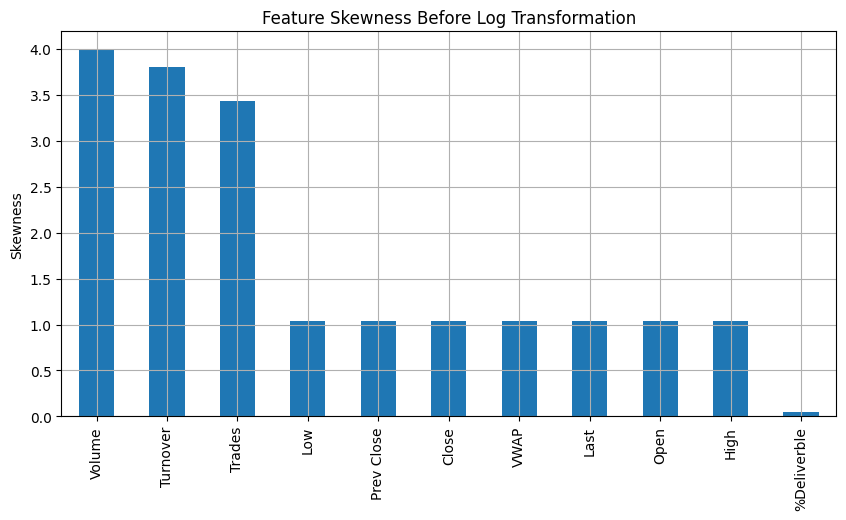

In [45]:
skew_before = numeric_df.skew(numeric_only=True).sort_values(ascending=False)

skew_df = pd.DataFrame({
    "Skewness Before Log": skew_before
})

display(skew_df)

plt.figure(figsize=(10, 5))
skew_before.plot(kind="bar")
plt.title("Feature Skewness Before Log Transformation")
plt.ylabel("Skewness")
plt.grid(True)
plt.show()

## Log transformation on heavily skewed columns

I applied `log1p` transformation on:

- Volume
- Turnover
- Trades

`log1p(x)` means `log(1 + x)`.  
It is useful because these columns are positive and contain large spikes.

This step is done before train-test split because log transformation does not learn any parameter from the data.  
After this, the data is split chronologically and scaling is fitted only on training data.

Log transformed columns: ['Volume', 'Turnover', 'Trades']


,Skewness Before Log,Skewness After Log
Prev Close,1.036880,1.036880
Open,1.035548,1.035548
High,1.033220,1.033220
Low,1.041669,1.041669
Last,1.035744,1.035744
Close,1.036790,1.036790
VWAP,1.036532,1.036532
Volume,3.991935,0.011818
Turnover,3.802325,-0.165022
Trades,3.436117,-0.121655


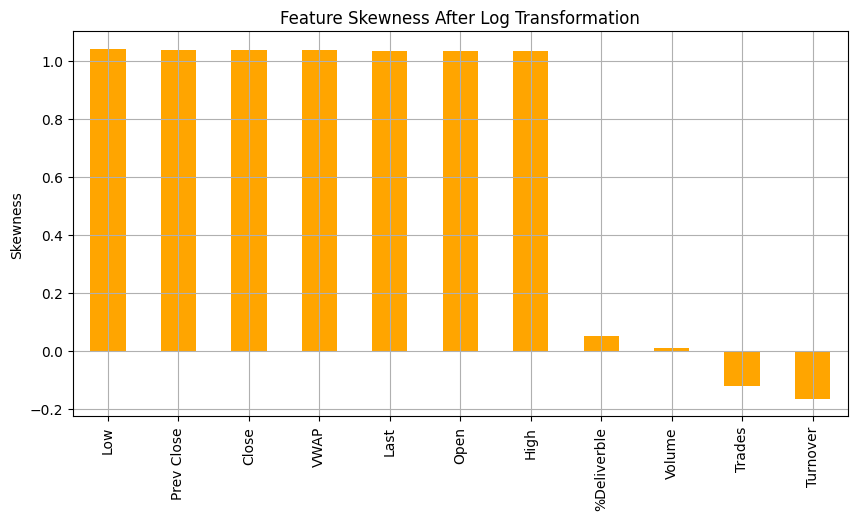

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,%Deliverble
0,62.940391,62.971009,64.961179,62.868949,63.991609,64.486600,63.992630,8.838552,26.792298,7.256297,0.4971
1,64.486600,63.787489,65.206123,63.277189,64.706029,64.649896,64.914231,7.926603,25.894434,6.070738,0.6204
2,64.649896,63.802798,65.093857,63.277189,63.583369,63.787489,63.796675,10.847938,28.798734,4.912655,0.9900
3,63.787489,63.277189,65.420449,62.394370,62.394370,62.664829,62.872011,8.602820,26.538861,5.594711,0.7918
4,62.664829,61.644230,63.680326,61.644230,63.266983,63.190438,63.045513,8.698181,26.636996,5.613128,0.6799


In [46]:
raw_numeric_df = numeric_df.copy()

processed_df = numeric_df.copy()

LOG_FEATURES = ["Volume", "Turnover", "Trades"]

for col in LOG_FEATURES:
    processed_df[col] = np.log1p(processed_df[col])

print("Log transformed columns:", LOG_FEATURES)

skew_after = processed_df.skew(numeric_only=True).sort_values(ascending=False)

skew_compare_df = pd.DataFrame({
    "Skewness Before Log": numeric_df.skew(numeric_only=True),
    "Skewness After Log": processed_df.skew(numeric_only=True)
})

display(skew_compare_df)

plt.figure(figsize=(10, 5))
skew_after.plot(kind="bar", color="orange")
plt.title("Feature Skewness After Log Transformation")
plt.ylabel("Skewness")
plt.grid(True)
plt.show()

display(processed_df.head())

## Visualizing cleaned time-series

The close price and volume are plotted after cleaning.  
Volume is also shown after log transformation because raw volume contains large spikes.

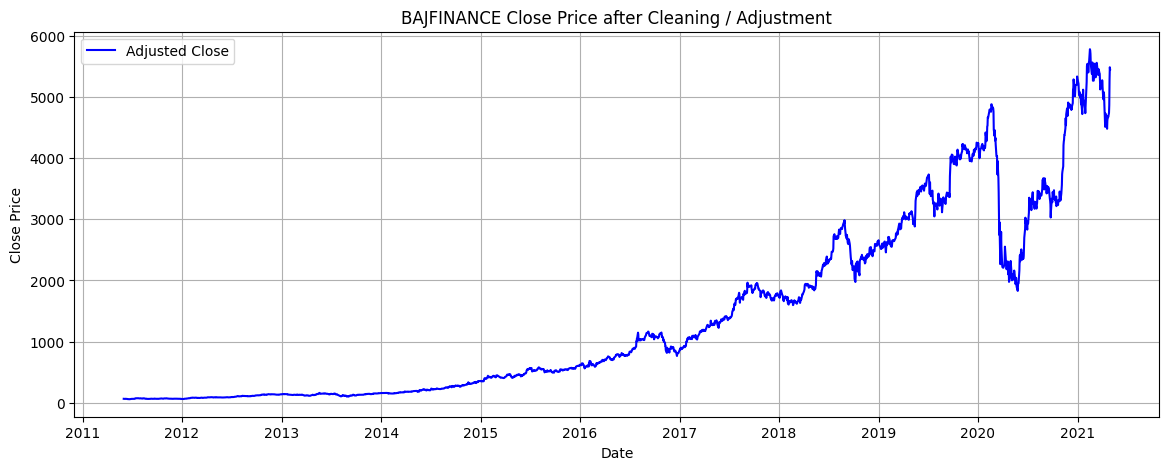

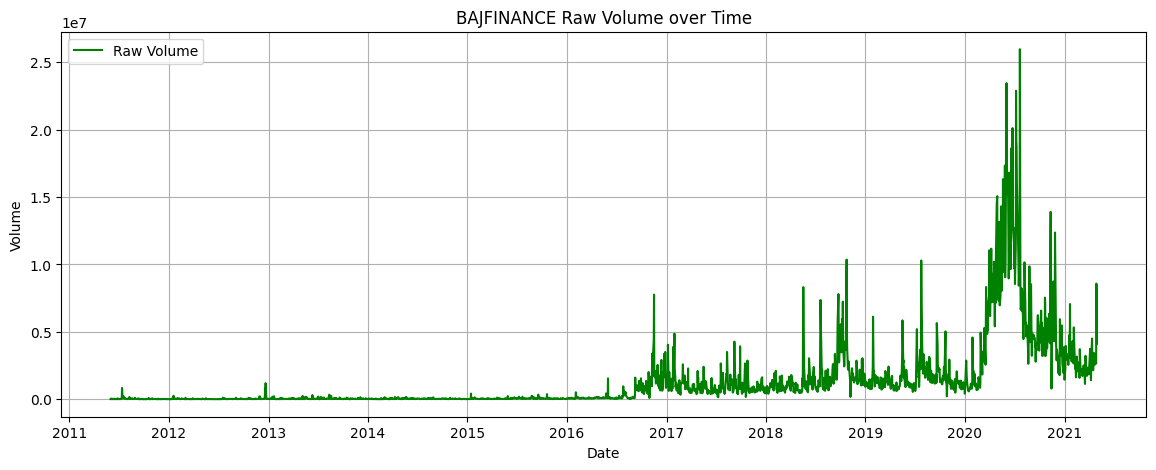

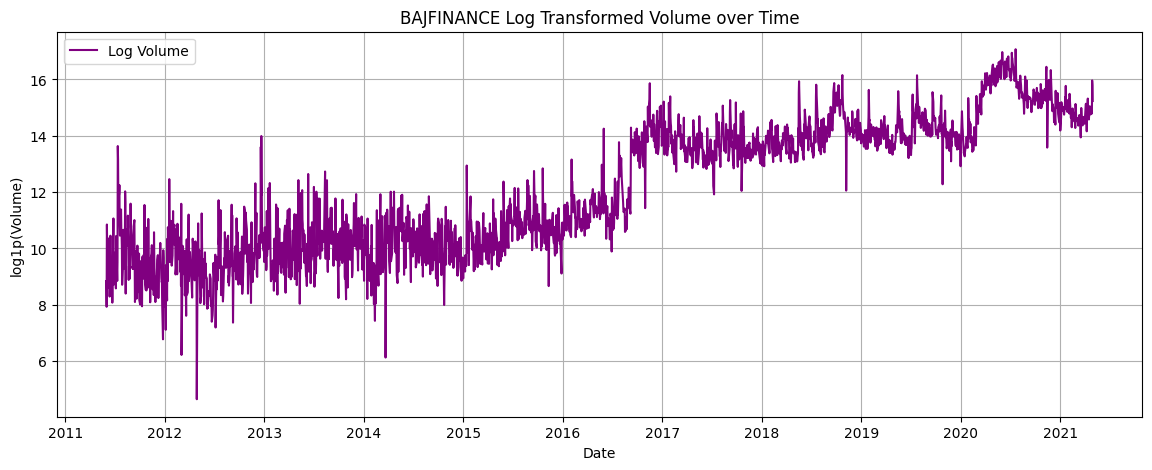

In [47]:
plt.figure(figsize=(14, 5))
plt.plot(date_series, numeric_df["Close"], label="Adjusted Close", color="blue")
plt.title("BAJFINANCE Close Price after Cleaning / Adjustment")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(date_series, numeric_df["Volume"], label="Raw Volume", color="green")
plt.title("BAJFINANCE Raw Volume over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(date_series, processed_df["Volume"], label="Log Volume", color="purple")
plt.title("BAJFINANCE Log Transformed Volume over Time")
plt.xlabel("Date")
plt.ylabel("log1p(Volume)")
plt.legend()
plt.grid(True)
plt.show()

## Train, validation, and test split

Since this is time-series data, random splitting is not used.

The data is split chronologically:

- 80% training data
- 10% validation data
- 10% test data

This prevents future data from leaking into the training process.

In [48]:
feature_names = processed_df.columns.tolist()
data = processed_df.values.astype(np.float32)

num_features = data.shape[1]

print("Features used:", feature_names)
print("Number of features:", num_features)
print("Data shape:", data.shape)
print("Number of dates:", len(date_series))

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', '%Deliverble']
Number of features: 11
Data shape: (2456, 11)
Number of dates: 2456


In [49]:
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

n = len(data)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

train_dates = date_series.iloc[:train_end].reset_index(drop=True)
val_dates = date_series.iloc[train_end:val_end].reset_index(drop=True)
test_dates = date_series.iloc[val_end:].reset_index(drop=True)

print("Train data shape:", train_data.shape)
print("Validation data shape:", val_data.shape)
print("Test data shape:", test_data.shape)

print("\nTrain date range:", train_dates.min(), "to", train_dates.max())
print("Validation date range:", val_dates.min(), "to", val_dates.max())
print("Test date range:", test_dates.min(), "to", test_dates.max())

Train data shape: (1964, 11)
Validation data shape: (246, 11)
Test data shape: (246, 11)

Train date range: 2011-06-01 00:00:00 to 2019-05-07 00:00:00
Validation date range: 2019-05-08 00:00:00 to 2020-05-07 00:00:00
Test date range: 2020-05-08 00:00:00 to 2021-04-30 00:00:00


## Scaling after train-test split

StandardScaler is used after log transformation.

The scaler is fitted only on the training data.  
The same scaler is used to transform validation and test data.

This avoids data leakage.

In [50]:
scaler = StandardScaler()

train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

train_data_scaled = train_data_scaled.astype(np.float32)
val_data_scaled = val_data_scaled.astype(np.float32)
test_data_scaled = test_data_scaled.astype(np.float32)

print("Scaled train data shape:", train_data_scaled.shape)
print("Scaled validation data shape:", val_data_scaled.shape)
print("Scaled test data shape:", test_data_scaled.shape)

scale_check_df = pd.DataFrame({
    "Train Mean": train_data_scaled.mean(axis=0),
    "Train Std": train_data_scaled.std(axis=0),
    "Validation Mean": val_data_scaled.mean(axis=0),
    "Validation Std": val_data_scaled.std(axis=0),
    "Test Mean": test_data_scaled.mean(axis=0),
    "Test Std": test_data_scaled.std(axis=0)
}, index=feature_names)

display(scale_check_df)

Scaled train data shape: (1964, 11)
Scaled validation data shape: (246, 11)
Scaled test data shape: (246, 11)


,Train Mean,Train Std,Validation Mean,Validation Std,Test Mean,Test Std
Prev Close,0.000000e+00,1.0,3.361993,0.794781,3.791250,1.303080
Open,0.000000e+00,1.0,3.355927,0.793210,3.793093,1.298362
High,0.000000e+00,1.0,3.362172,0.769808,3.818884,1.290368
Low,3.107697e-08,1.0,3.339208,0.829853,3.779711,1.307269
Last,-3.107697e-08,1.0,3.351946,0.800542,3.798024,1.294429
Close,0.000000e+00,1.0,3.350424,0.801088,3.799933,1.297252
VWAP,3.107697e-08,1.0,3.351374,0.798478,3.799456,1.297469
Volume,0.000000e+00,1.0,1.500681,0.390915,1.982051,0.341098
Turnover,-3.107697e-08,1.0,1.638003,0.291865,2.107558,0.225553
Trades,-3.107697e-08,1.0,1.633906,0.417713,2.020767,0.290078


## Creating input-output sequences

The model uses:

- Input: previous 10 trading days
- Output: next 5 trading days

A sliding window is used to create more training samples from the time-series data.

In [51]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5

# One-day sliding window gives more training samples
STRIDE = 1
OVERLAP = 10

BATCH_SIZE = 32

print("Input steps:", INPUT_STEPS)
print("Output steps:", OUTPUT_STEPS)
print("Stride:", STRIDE)
print("Effective overlap:", OVERLAP)
print("Batch size:", BATCH_SIZE)

Input steps: 10
Output steps: 5
Stride: 1
Effective overlap: 10
Batch size: 32


In [52]:
def create_sequences(data_array, date_array, input_steps=10, output_steps=5, stride=1):
    X = []
    y = []
    y_dates = []
    
    total_len = len(data_array)
    
    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i : i + input_steps])
        y.append(data_array[i + input_steps : i + input_steps + output_steps])
        y_dates.append(date_array.iloc[i + input_steps : i + input_steps + output_steps].values)
    
    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(y_dates)
    )


X_train, y_train, train_y_dates = create_sequences(
    train_data_scaled, train_dates, INPUT_STEPS, OUTPUT_STEPS, STRIDE
)

X_val, y_val, val_y_dates = create_sequences(
    val_data_scaled, val_dates, INPUT_STEPS, OUTPUT_STEPS, STRIDE
)

X_test, y_test, test_y_dates = create_sequences(
    test_data_scaled, test_dates, INPUT_STEPS, OUTPUT_STEPS, STRIDE
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nOne input sample shape:", X_train[0].shape)
print("One output sample shape:", y_train[0].shape)

X_train shape: (1950, 10, 11)
y_train shape: (1950, 5, 11)
X_val shape: (232, 10, 11)
y_val shape: (232, 5, 11)
X_test shape: (232, 10, 11)
y_test shape: (232, 5, 11)

One input sample shape: (10, 11)
One output sample shape: (5, 11)


## Creating PyTorch Dataset and DataLoader

The sequence data is converted into PyTorch tensors using a custom Dataset class.

In [53]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [54]:
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

X_batch, y_batch = next(iter(train_loader))

print("Batch input shape:", X_batch.shape)
print("Batch output shape:", y_batch.shape)

Batch input shape: torch.Size([32, 10, 11])
Batch output shape: torch.Size([32, 5, 11])


## LSTM model

The LSTM receives input in the shape:

`batch_size × input_steps × features`

Here:

- input_steps = 10
- features = 11

The model predicts the next 5 days for all 11 features.

I used a residual style output.  
Instead of predicting the complete future value directly, the model predicts the change from the last input day.

This makes the forecast more stable for stock price data.

In [55]:
class ResidualLSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_steps, num_features, dropout=0.2):
        super(ResidualLSTMForecaster, self).__init__()
        
        self.output_steps = output_steps
        self.num_features = num_features
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_steps * num_features)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        
        last_hidden = lstm_out[:, -1, :]
        last_hidden = self.layer_norm(last_hidden)
        
        delta = self.fc(last_hidden)
        delta = delta.view(-1, self.output_steps, self.num_features)
        
        # Residual connection: future = last input value + predicted change
        last_input = x[:, -1:, :]
        base = last_input.repeat(1, self.output_steps, 1)
        
        out = base + delta
        
        return out

## Model configuration and training setup

Mean Squared Error is used because this is a regression problem.

AdamW optimizer is used with weight decay for regularization.  
Gradient clipping is also used during training to avoid unstable updates.

In [56]:
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.25

LR = 0.0007
EPOCHS = 150
PATIENCE = 15

model = ResidualLSTMForecaster(
    input_size=num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_steps=OUTPUT_STEPS,
    num_features=num_features,
    dropout=DROPOUT
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTotal parameters:", total_params)
print("Trainable parameters:", trainable_params)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=7
)

print("\nLearning rate:", LR)
print("Epochs:", EPOCHS)
print("Patience:", PATIENCE)
print("Batch size:", BATCH_SIZE)

ResidualLSTMForecaster(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.25)
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=55, bias=True)
  )
)

Total parameters: 60855
Trainable parameters: 60855

Learning rate: 0.0007
Epochs: 150
Patience: 15
Batch size: 32


## Training and evaluation functions

In [57]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    avg_loss = running_loss / len(loader.dataset)
    return avg_loss


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())
    
    avg_loss = running_loss / len(loader.dataset)
    
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()
    
    return avg_loss, all_preds, all_targets

## Model training with early stopping

The best model is saved using the lowest validation loss.

In [58]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_no_improve = 0

best_model_path = "best_residual_lstm_bajfinance.pt"

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss - 1e-7:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
    
    current_lr = optimizer.param_groups[0]["lr"]
    
    print(
        f"Epoch [{epoch + 1:03d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Gap: {val_loss - train_loss:.6f} | "
        f"LR: {current_lr:.6f}"
    )
    
    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

model.load_state_dict(torch.load(best_model_path, map_location=device))

print("\nBest validation loss:", best_val_loss)

Epoch [001/150] | Train Loss: 0.126080 | Val Loss: 0.075197 | Gap: -0.050883 | LR: 0.000700
Epoch [002/150] | Train Loss: 0.117112 | Val Loss: 0.073397 | Gap: -0.043714 | LR: 0.000700
Epoch [003/150] | Train Loss: 0.114797 | Val Loss: 0.073179 | Gap: -0.041619 | LR: 0.000700
Epoch [004/150] | Train Loss: 0.104214 | Val Loss: 0.073378 | Gap: -0.030836 | LR: 0.000700
Epoch [005/150] | Train Loss: 0.091713 | Val Loss: 0.072447 | Gap: -0.019266 | LR: 0.000700
Epoch [006/150] | Train Loss: 0.086756 | Val Loss: 0.073408 | Gap: -0.013347 | LR: 0.000700
Epoch [007/150] | Train Loss: 0.083780 | Val Loss: 0.069581 | Gap: -0.014199 | LR: 0.000700
Epoch [008/150] | Train Loss: 0.081368 | Val Loss: 0.074310 | Gap: -0.007058 | LR: 0.000700
Epoch [009/150] | Train Loss: 0.080198 | Val Loss: 0.073286 | Gap: -0.006912 | LR: 0.000700
Epoch [010/150] | Train Loss: 0.079513 | Val Loss: 0.072482 | Gap: -0.007031 | LR: 0.000700
Epoch [011/150] | Train Loss: 0.079889 | Val Loss: 0.074354 | Gap: -0.005535 | L

## Training and validation loss plot

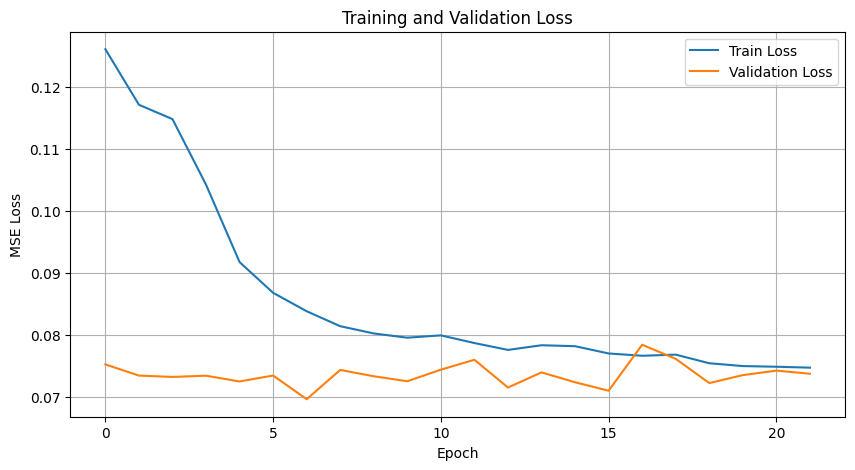

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

## Test evaluation

The model is evaluated on unseen test data.

In [60]:
test_loss, predictions_scaled, targets_scaled = evaluate(model, test_loader, criterion, device)

print("Final Test Loss on scaled data:", test_loss)
print("Predictions shape:", predictions_scaled.shape)
print("Targets shape:", targets_scaled.shape)

Final Test Loss on scaled data: 0.06040709953883599
Predictions shape: (232, 5, 11)
Targets shape: (232, 5, 11)


## Inverse transformation

To convert predictions back to original scale:

1. First inverse StandardScaler is applied.
2. Then `expm1` is applied to reverse the log transformation for:
   - Volume
   - Turnover
   - Trades

In [61]:
def inverse_transform_3d(data_3d, scaler, feature_names, log_features):
    original_shape = data_3d.shape
    
    flat_data = data_3d.reshape(-1, original_shape[-1])
    
    # Reverse StandardScaler
    inverse_data = scaler.inverse_transform(flat_data)
    
    # Reverse log1p transformation
    for col in log_features:
        idx = feature_names.index(col)
        inverse_data[:, idx] = np.expm1(inverse_data[:, idx])
        inverse_data[:, idx] = np.maximum(inverse_data[:, idx], 0)
    
    inverse_data = inverse_data.reshape(original_shape)
    
    return inverse_data


predictions_orig = inverse_transform_3d(predictions_scaled, scaler, feature_names, LOG_FEATURES)
targets_orig = inverse_transform_3d(targets_scaled, scaler, feature_names, LOG_FEATURES)

print("Original scale predictions shape:", predictions_orig.shape)
print("Original scale targets shape:", targets_orig.shape)

Original scale predictions shape: (232, 5, 11)
Original scale targets shape: (232, 5, 11)


## Performance metrics

The model performance is evaluated using:

1. MSE
2. RMSE
3. MAE

Metrics are calculated on scaled data and also on original scale for important features.

In [62]:
def calculate_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    return mse, rmse, mae


mse_scaled, rmse_scaled, mae_scaled = calculate_metrics(targets_scaled, predictions_scaled)

metrics_scaled_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE"],
    "Value on Scaled Data": [mse_scaled, rmse_scaled, mae_scaled]
})

display(metrics_scaled_df)

,Metric,Value on Scaled Data
0,MSE,0.060407
1,RMSE,0.245779
2,MAE,0.178866


In [63]:
PLOT_FEATURE = "Close"
close_idx = feature_names.index(PLOT_FEATURE)

mse_close, rmse_close, mae_close = calculate_metrics(
    targets_orig[:, :, close_idx],
    predictions_orig[:, :, close_idx]
)

close_metrics_df = pd.DataFrame({
    "Feature": ["Close"],
    "MSE": [mse_close],
    "RMSE": [rmse_close],
    "MAE": [mae_close]
})

display(close_metrics_df)

,Feature,MSE,RMSE,MAE
0,Close,37211.132812,192.901871,141.550415


In [64]:
feature_metric_rows = []

for i, feature in enumerate(feature_names):
    mse_f, rmse_f, mae_f = calculate_metrics(
        targets_orig[:, :, i],
        predictions_orig[:, :, i]
    )
    
    feature_metric_rows.append({
        "Feature": feature,
        "MSE": mse_f,
        "RMSE": rmse_f,
        "MAE": mae_f
    })

feature_metrics_df = pd.DataFrame(feature_metric_rows)

display(feature_metrics_df)

,Feature,MSE,RMSE,MAE
0,Prev Close,3.538219e+04,1.881015e+02,1.392848e+02
1,Open,3.658203e+04,1.912643e+02,1.419895e+02
2,High,3.521081e+04,1.876454e+02,1.353758e+02
3,Low,3.455177e+04,1.858811e+02,1.365359e+02
4,Last,3.843709e+04,1.960538e+02,1.425800e+02
5,Close,3.721113e+04,1.929019e+02,1.415504e+02
6,VWAP,3.449948e+04,1.857404e+02,1.347445e+02
7,Volume,1.053582e+13,3.245892e+06,1.965055e+06
8,Turnover,1.459120e+30,1.207940e+15,7.752229e+14
9,Trades,1.531114e+10,1.237382e+05,7.871676e+04


## Date-wise True vs Predicted Close Price

The model predicts 5 future days for every input sequence.

For a clear date-wise graph, I plotted Horizon 1, which means the first predicted day from the 5-day forecast window.

This avoids mixing multiple forecast horizons in one graph.

,Date,True Close,Predicted Close,Absolute Error
0,2020-05-22,1895.300049,1988.923096,93.623047
1,2020-05-26,1829.000122,1887.591431,58.591309
2,2020-05-27,1936.449951,1823.119629,113.330322
3,2020-05-28,1947.699951,1936.440674,11.259277
4,2020-05-29,1953.650024,1948.820068,4.829956
5,2020-06-01,2160.850098,1949.444092,211.406006
6,2020-06-02,2346.199951,2154.891113,191.308838
7,2020-06-03,2411.899902,2344.723877,67.176025
8,2020-06-04,2313.050049,2406.600098,93.550049
9,2020-06-05,2390.350098,2320.474609,69.875488


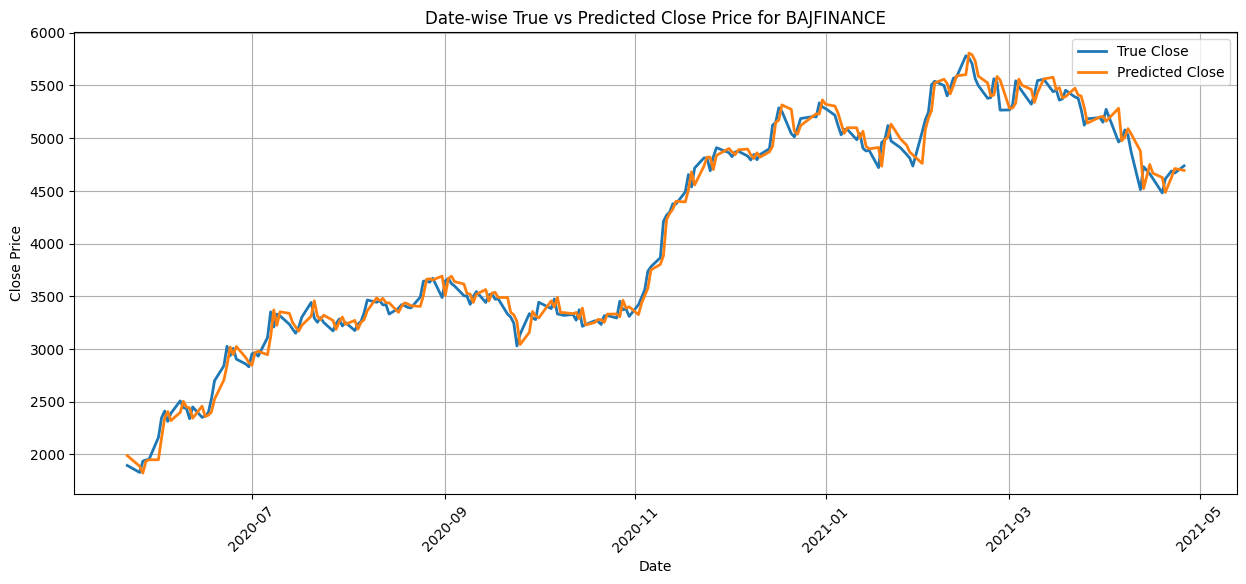

In [65]:
PLOT_FEATURE = "Close"
HORIZON = 0

feature_idx = feature_names.index(PLOT_FEATURE)

plot_dates = pd.to_datetime(test_y_dates[:, HORIZON])

true_close = targets_orig[:, HORIZON, feature_idx]
pred_close = predictions_orig[:, HORIZON, feature_idx]

plot_df = pd.DataFrame({
    "Date": plot_dates,
    "True Close": true_close,
    "Predicted Close": pred_close
})

plot_df = plot_df.sort_values("Date").reset_index(drop=True)

plot_df["Absolute Error"] = abs(plot_df["True Close"] - plot_df["Predicted Close"])

display(plot_df.head(15))

plt.figure(figsize=(15, 6))
plt.plot(plot_df["Date"], plot_df["True Close"], label="True Close", linewidth=2)
plt.plot(plot_df["Date"], plot_df["Predicted Close"], label="Predicted Close", linewidth=2)

plt.title("Date-wise True vs Predicted Close Price for BAJFINANCE")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## Horizon-wise Close price metrics

Since the output window is 5 days, I also calculated metrics separately for each forecast horizon.

In [66]:
horizon_rows = []

for h in range(OUTPUT_STEPS):
    mse_h, rmse_h, mae_h = calculate_metrics(
        targets_orig[:, h, close_idx],
        predictions_orig[:, h, close_idx]
    )
    
    horizon_rows.append({
        "Forecast Horizon": f"Day {h + 1}",
        "MSE": mse_h,
        "RMSE": rmse_h,
        "MAE": mae_h
    })

horizon_metrics_df = pd.DataFrame(horizon_rows)

display(horizon_metrics_df)

,Forecast Horizon,MSE,RMSE,MAE
0,Day 1,11370.150391,106.630905,83.434303
1,Day 2,22870.603516,151.230301,119.481628
2,Day 3,35535.378906,188.508301,147.148575
3,Day 4,51093.632812,226.039001,170.140182
4,Day 5,65185.898438,255.315292,187.547379


## Additional feature plots

The model predicts all 11 features.  
Some important features are plotted below for Horizon 1.

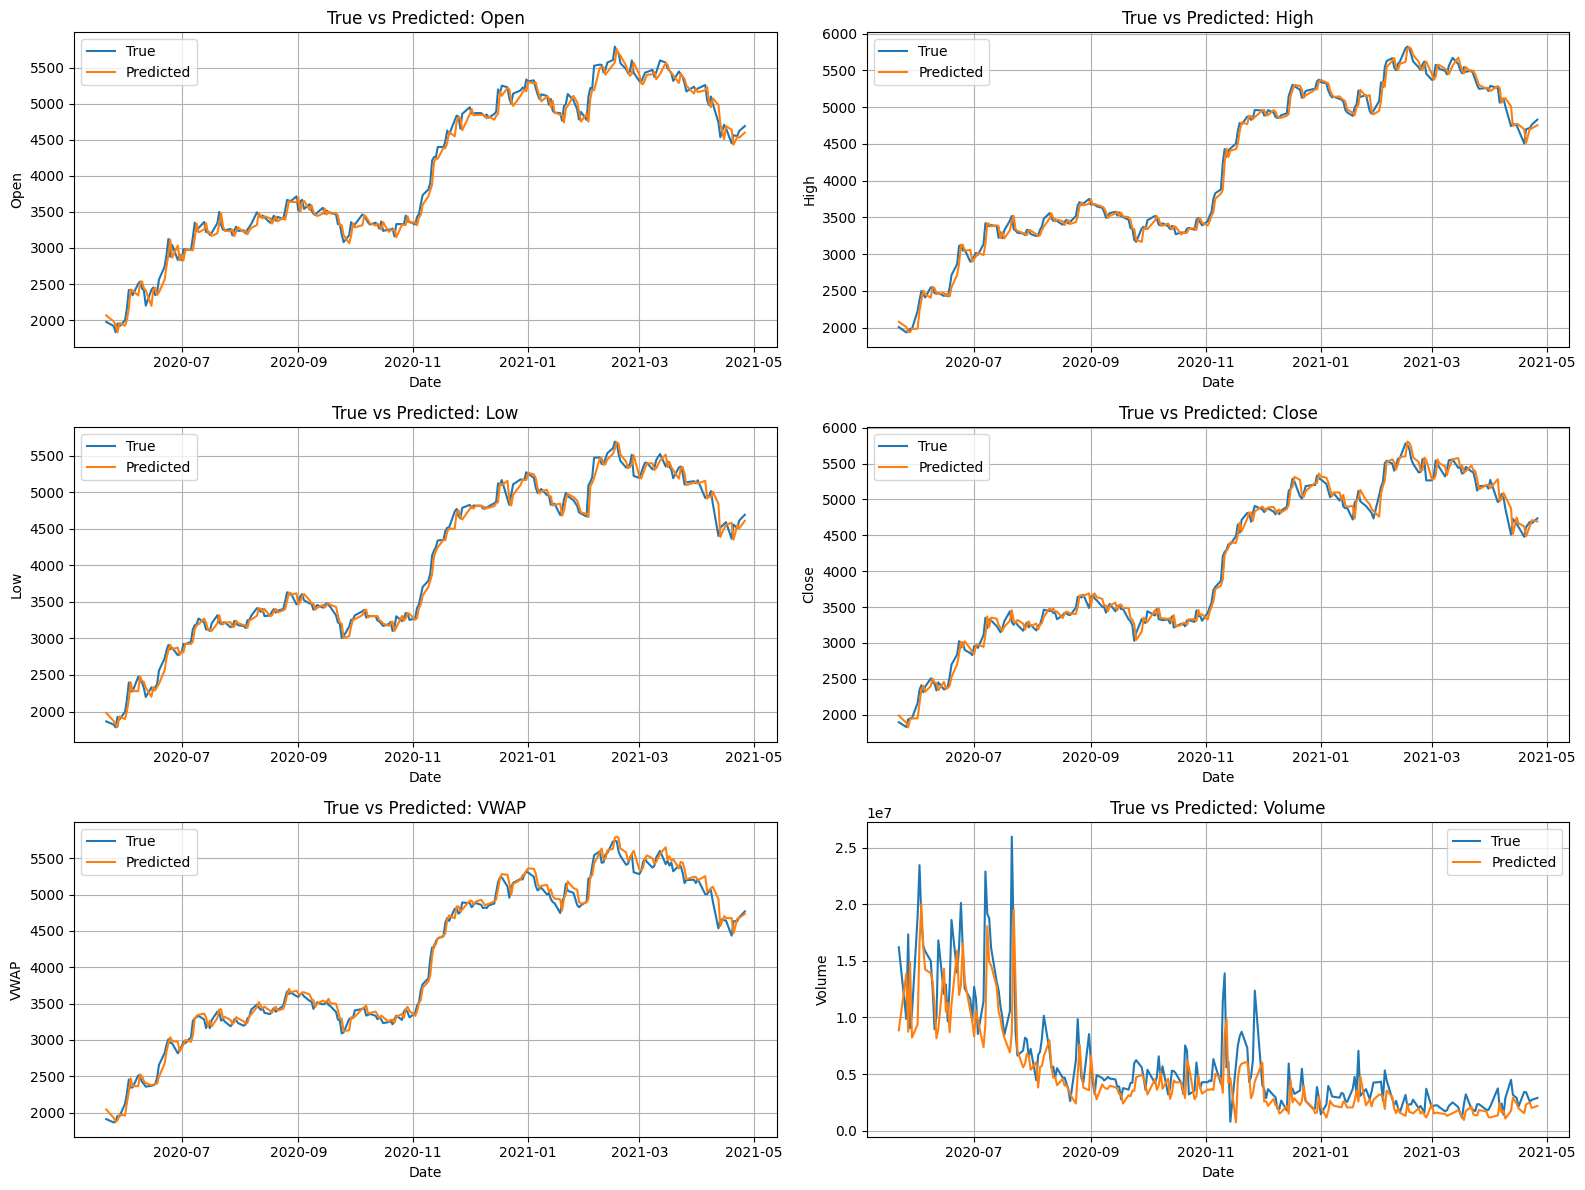

In [67]:
selected_plot_features = ["Open", "High", "Low", "Close", "VWAP", "Volume"]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, feature in zip(axes, selected_plot_features):
    idx = feature_names.index(feature)
    
    true_values = targets_orig[:, HORIZON, idx]
    pred_values = predictions_orig[:, HORIZON, idx]
    
    temp_df = pd.DataFrame({
        "Date": plot_dates,
        "True": true_values,
        "Predicted": pred_values
    })
    
    temp_df = temp_df.sort_values("Date").reset_index(drop=True)
    
    ax.plot(temp_df["Date"], temp_df["True"], label="True")
    ax.plot(temp_df["Date"], temp_df["Predicted"], label="Predicted")
    ax.set_title(f"True vs Predicted: {feature}")
    ax.set_xlabel("Date")
    ax.set_ylabel(feature)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Final summary

This assignment implemented multi-output time-series forecasting using LSTM in PyTorch.

Main points:

- Dataset used: `BAJFINANCE.csv`
- Input window: previous 10 trading days
- Output window: next 5 trading days
- Number of features: 11
- Log transformation applied on heavily skewed columns
- StandardScaler fitted only on training data
- Model used: LSTM
- Evaluation metrics: MSE, RMSE, MAE
- Date-wise True vs Predicted Close Price plot is shown